# Time Series Analysis
### STL Decomposition and Granger Causality Test

In [9]:
# Standard Library Imports
import io
import contextlib

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split

# Time Series Analysis
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR

In [10]:
# Load data and convert time column
df = pd.read_csv('../all_data_files/cleaned_dataset_per_device.csv')
df['time'] = pd.to_datetime(df['time'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2079534 entries, 0 to 2079533
Data columns (total 20 columns):
 #   Column       Dtype              
---  ------       -----              
 0   time         datetime64[ns, UTC]
 1   device_id    object             
 2   co2          float64            
 3   humidity     float64            
 4   pm25         float64            
 5   pressure     float64            
 6   temperature  float64            
 7   rssi         float64            
 8   snr          float64            
 9   SF           int64              
 10  frequency    float64            
 11  f_count      float64            
 12  p_count      float64            
 13  toa          float64            
 14  distance     int64              
 15  c_walls      int64              
 16  w_walls      int64              
 17  exp_pl       float64            
 18  n_power      float64            
 19  esp          float64            
dtypes: datetime64[ns, UTC](1), float64(14), int64(

,time,device_id,co2,humidity,pm25,pressure,temperature,rssi,snr,SF,frequency,f_count,p_count,toa,distance,c_walls,w_walls,exp_pl,n_power,esp
0,2024-10-01 00:01:07.420593+00:00,ED5,440.0,45.46,0.46,313.80,22.41,-102.0,10.2,9,868.1,9868.0,10756.0,0.246784,40,2,2,119.26,-112.596121,-102.396121
1,2024-10-01 00:01:25.764905+00:00,ED2,451.0,40.59,0.43,314.81,22.83,-66.0,11.0,10,867.9,5815.0,6642.0,0.452608,23,0,2,83.26,-77.331956,-66.331956
2,2024-10-01 00:01:50.313519+00:00,ED4,435.0,37.33,0.05,315.54,24.06,-119.0,-1.8,10,867.1,9335.0,10753.0,0.452608,37,0,5,136.26,-121.202895,-123.002895
3,2024-10-01 00:02:07.467816+00:00,ED5,449.0,45.43,0.40,313.84,22.41,-100.0,10.8,9,867.7,9869.0,10757.0,0.246784,40,2,2,117.26,-111.146992,-100.346992
4,2024-10-01 00:02:25.817808+00:00,ED2,451.0,40.57,0.21,314.80,22.84,-64.0,8.8,10,867.7,5816.0,6643.0,0.452608,23,0,2,81.26,-73.337795,-64.537795


In [11]:
# 80-20 stratified train-test split ensuring all 6 devices are included in both sets
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['device_id'], random_state=200)

# Sort by time for clarity in plotting
train_df = train_df.sort_values('time')
test_df = test_df.sort_values('time')

### Per Parameter Analysis

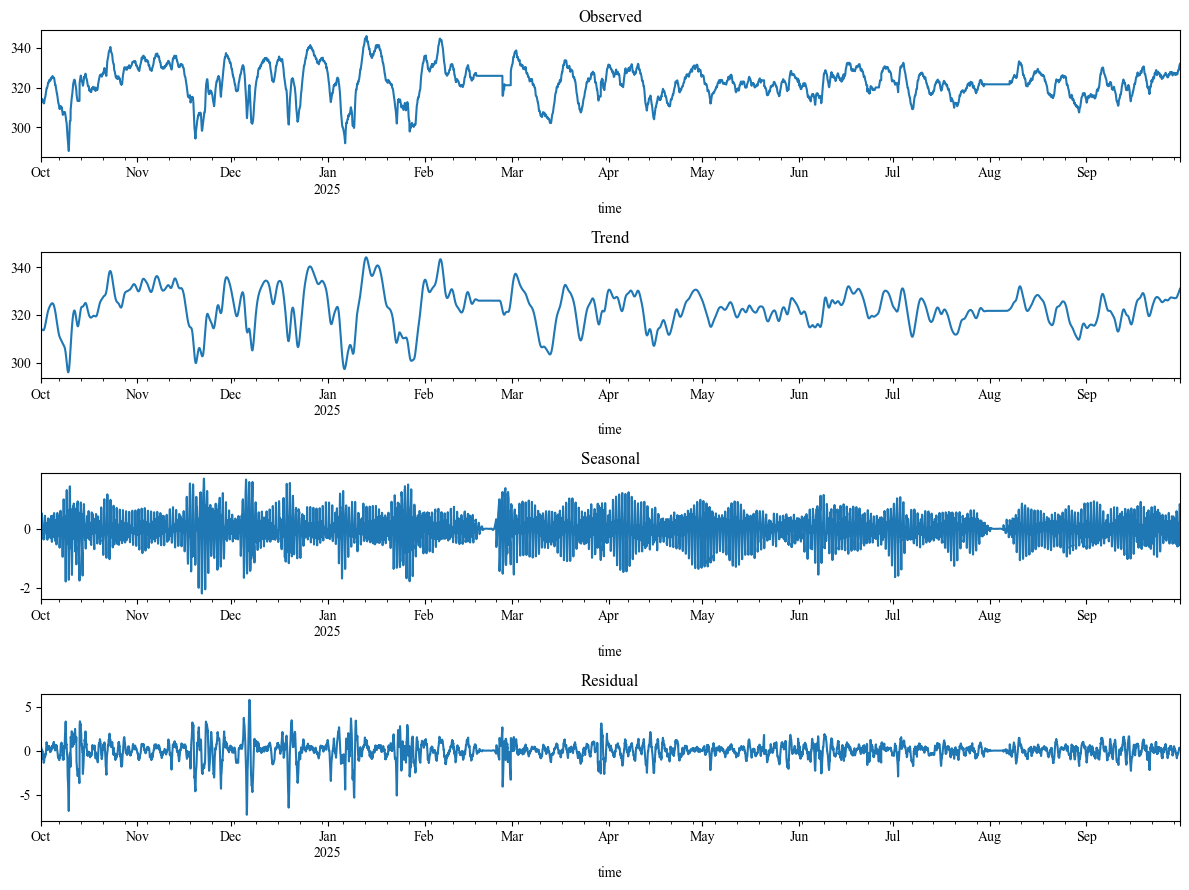

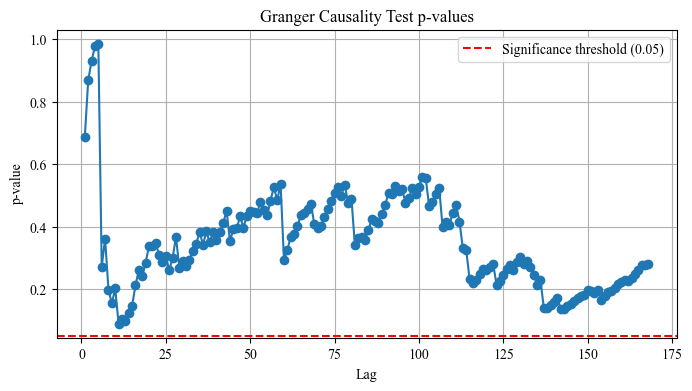


For pressure: 

Minimum p-value is 0.0888 at lag 11.
No significant Granger causality detected.



In [12]:
# Set the parameter to analyse
param = 'pressure'

# Decompose time series for the given parameter
param_series = train_df.set_index('time')[param].resample('1h').mean().ffill()
stl = STL(param_series, period=24).fit()  # period=24 for daily seasonality in hourly data

# Plot STL decomposition
fig, ax = plt.subplots(4, 1, figsize=(12, 9))
stl.observed.plot(ax=ax[0], title='Observed')
stl.trend.plot(ax=ax[1], title='Trend')
stl.seasonal.plot(ax=ax[2], title='Seasonal')
stl.resid.plot(ax=ax[3], title='Residual')
plt.tight_layout()
plt.show()

# Prepare data for Granger causality test
gc_data = pd.DataFrame({
    'RSSI': train_df.groupby(pd.Grouper(key='time', freq='1h'))['rssi'].mean(),
    param: param_series
}).dropna()

# Run Granger causality test and capture output
with contextlib.redirect_stdout(io.StringIO()):
    gc_results = grangercausalitytests(gc_data[['RSSI', param]], maxlag=168)

# Extract p-values and plot them
lags = range(1,169)  # lags 1 to 168
p_values = []

for lag in lags:
    # Extract p-value from the SSR-based F test.
    p = gc_results[lag][0]['ssr_ftest'][1]
    p_values.append(p)

# Plot p-values vs. lags
plt.figure(figsize=(8, 4))
plt.plot(list(lags), p_values, marker='o')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance threshold (0.05)')
plt.xlabel('Lag')
plt.ylabel('p-value')
plt.title('Granger Causality Test p-values')
plt.legend()
plt.grid(True)
plt.show()

# Summary analysis: determine the minimum p-value across all lags
lag_pvalues = {lag: gc_results[lag][0]['ssr_ftest'][1] for lag in lags}
min_pvalue = min(lag_pvalues.values())
min_lag = min(lag_pvalues, key=lag_pvalues.get)
print(f"\nFor {param}: \n\nMinimum p-value is {min_pvalue:.4f} at lag {min_lag}.")

if min_pvalue < 0.05:
    print("There is evidence of Granger causality.\n")
else:
    print("No significant Granger causality detected.\n")

#### STL Decomposition

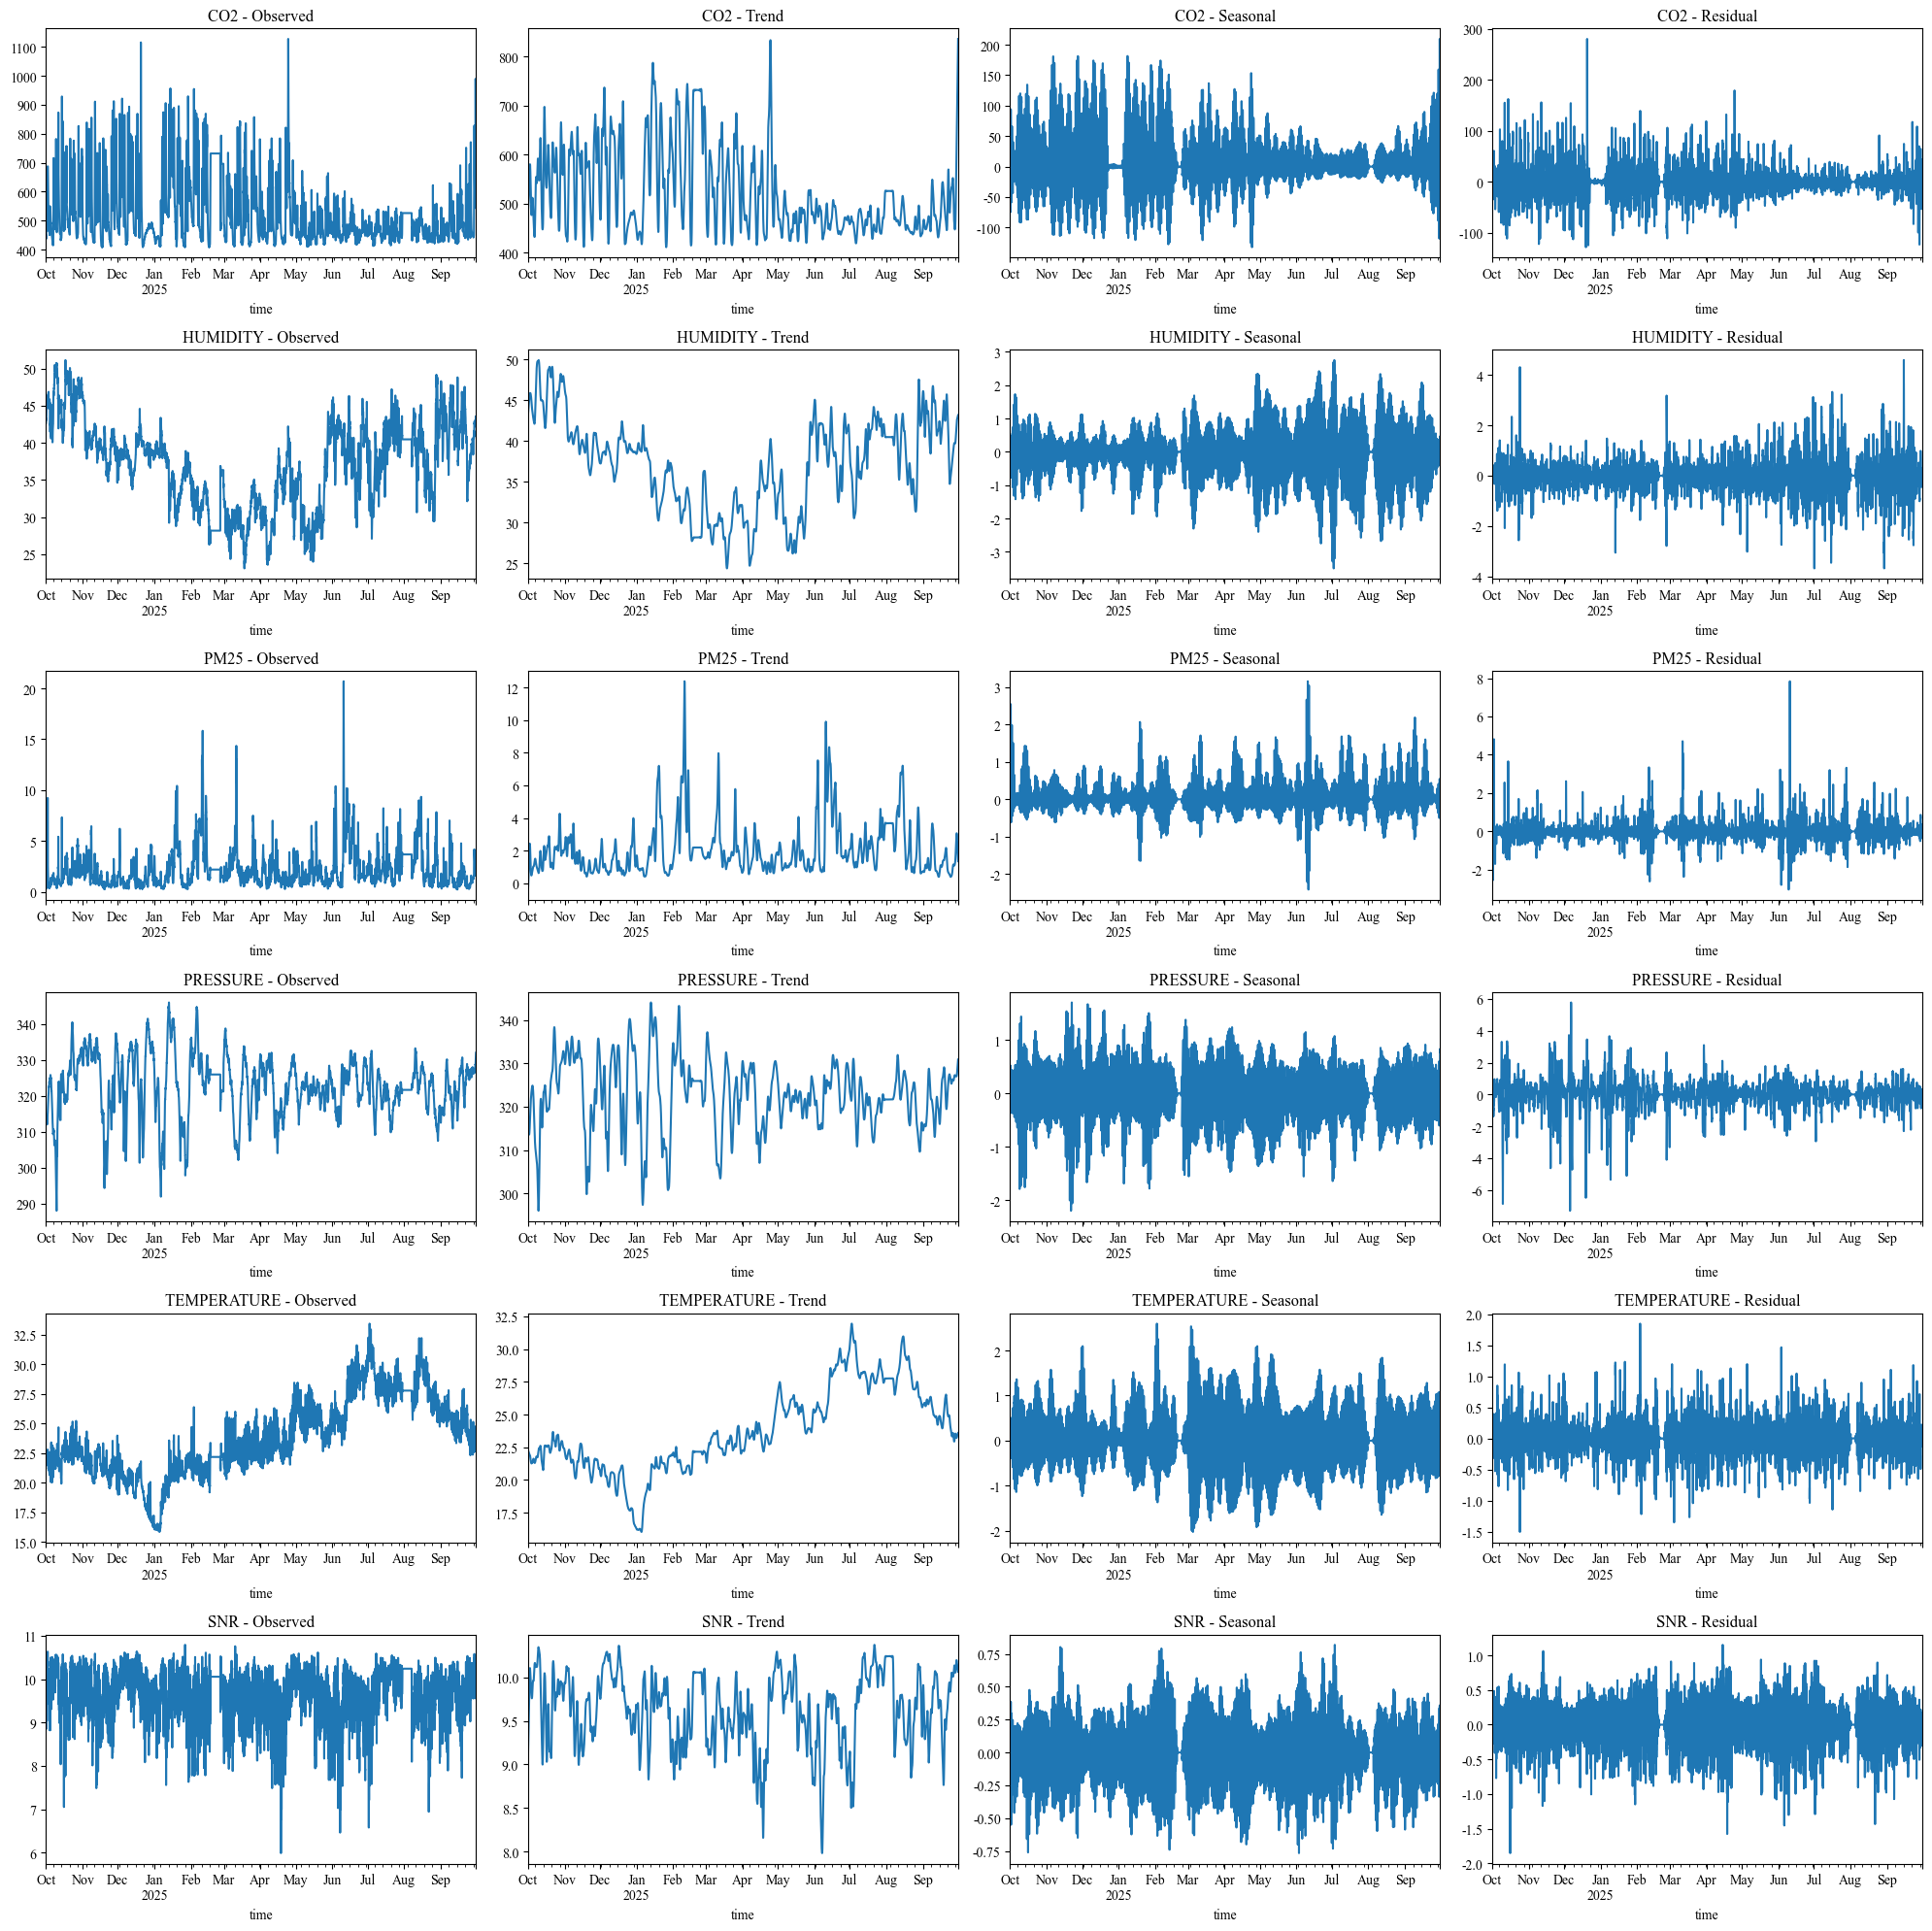

In [13]:
# List of parameters to analyze
parameters = ['co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr']

# Create a figure with 6 rows and 4 columns for subplots
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 20))  # We can adjust figure size as needed

# Loop over each parameter to perform STL decomposition and plot the 4 components on the corresponding row.
for i, param in enumerate(parameters):
    # Resample the time series (hourly mean) and fill missing values
    ts = train_df.set_index('time')[param].resample('1h').mean().ffill()
    
    # Perform STL decomposition with daily seasonality (period=24)
    stl = STL(ts, period=24).fit()
    
    # Plot each component in the appropriate column
    stl.observed.plot(ax=axes[i, 0], title=f'{param.upper()} - Observed')
    stl.trend.plot(ax=axes[i, 1], title=f'{param.upper()} - Trend')
    stl.seasonal.plot(ax=axes[i, 2], title=f'{param.upper()} - Seasonal')
    stl.resid.plot(ax=axes[i, 3], title=f'{param.upper()} - Residual')

plt.tight_layout()
plt.show()

#### Granger Causality Test

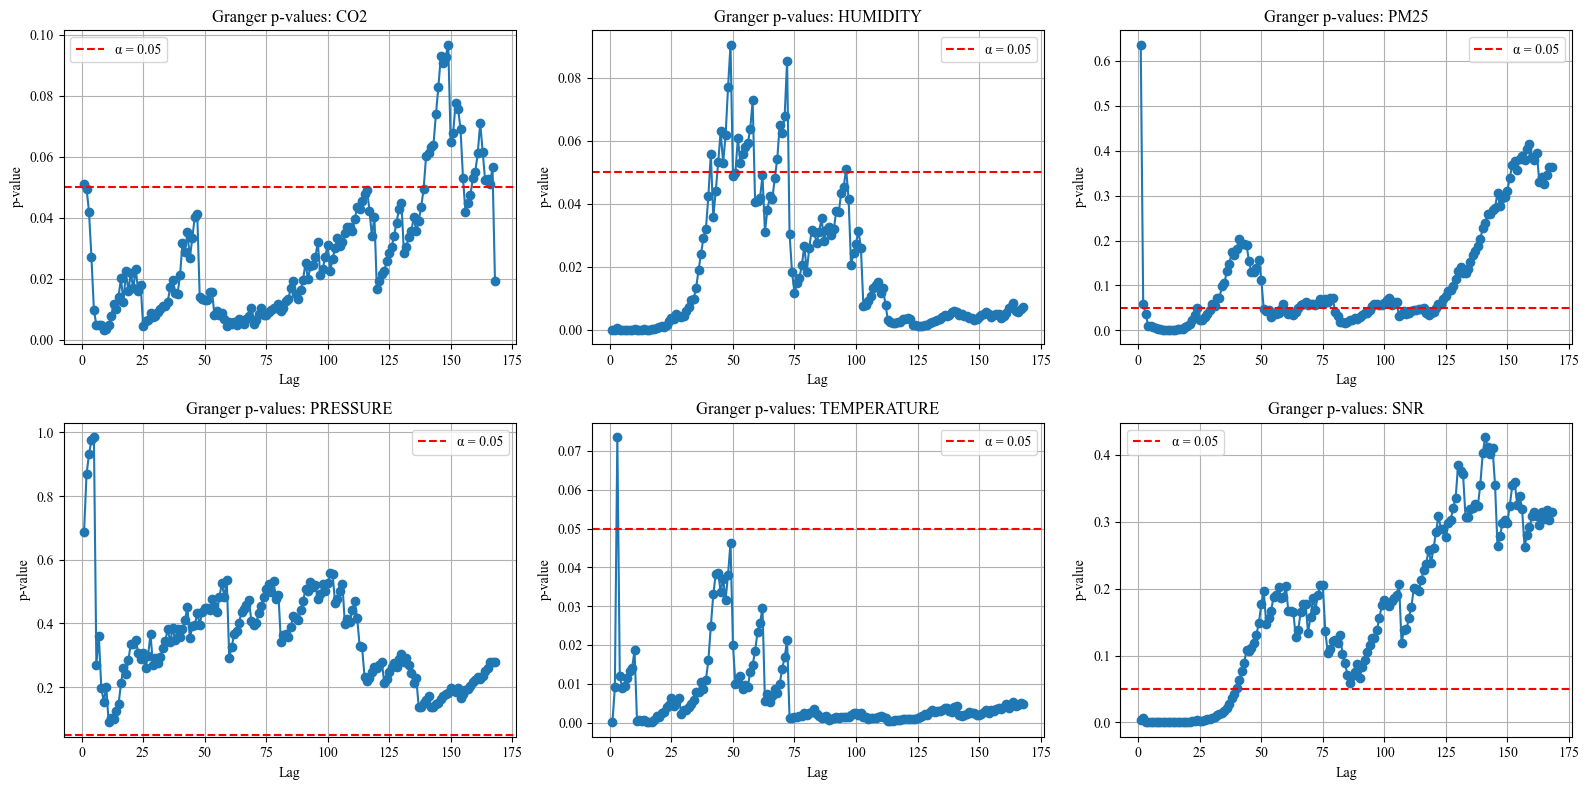


Granger Causality Summary (RSSI vs Parameter):



,Parameter,Min p-value,Lag,Evidence
0,CO2,0.003153,9,Yes
1,HUMIDITY,0.0,1,Yes
2,PM25,0.000776,13,Yes
3,PRESSURE,0.08881,11,No
4,TEMPERATURE,0.000013,1,Yes
5,SNR,0.000001,10,Yes


In [14]:
# Prepare a figure grid for p-value plots: 2 rows x 3 columns for our six parameters.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

# Dictionary to store summary results for each parameter
summary_results = {}

# List of parameters
for i, param in enumerate(parameters):
    # Resample RSSI and the parameter (hourly mean)
    rssi_ts = train_df.groupby(pd.Grouper(key='time', freq='1h'))['rssi'].mean()
    param_ts = train_df.groupby(pd.Grouper(key='time', freq='1h'))[param].mean()
    
    # Create a DataFrame for the two series and drop missing values
    gc_data = pd.DataFrame({'RSSI': rssi_ts, param.upper(): param_ts}).dropna()
    
    # Run Granger causality tests with output suppressed, using maxlag = 6
    with contextlib.redirect_stdout(io.StringIO()):
        gc_results = grangercausalitytests(gc_data[['RSSI', param.upper()]], maxlag=168)
    
    # Extract p-values (using ssr-based F test) for lags 1 to 168
    lags = range(1, 169)
    p_values = []
    lag_pvalues = {}
    for lag in lags:
        p_val = gc_results[lag][0]['ssr_ftest'][1]
        p_values.append(p_val)
        lag_pvalues[lag] = p_val
    
    # Plot p-values vs. lag on the corresponding subplot
    ax = axes[i]
    ax.plot(list(lags), p_values, marker='o')
    ax.axhline(y=0.05, color='red', linestyle='--', label='α = 0.05')
    ax.set_xlabel('Lag')
    ax.set_ylabel('p-value')
    ax.set_title(f'Granger p-values: {param.upper()}')
    ax.legend()
    ax.grid(True)
    
    # Determine the minimum p-value and corresponding lag
    min_p = min(lag_pvalues.values())
    min_lag = min(lag_pvalues, key=lag_pvalues.get)
    summary_results[param.upper()] = {'Min p-value': min_p, 'Lag': min_lag,
                                      'Evidence': 'Yes' if min_p < 0.05 else 'No'}

plt.tight_layout()
plt.show()

# Convert the summary_results dictionary into a DataFrame for a neat table display
summary_df = pd.DataFrame(summary_results).T  # transpose so each parameter is a row
summary_df.index.name = 'Parameter'
summary_df.reset_index(inplace=True)

# Display summary table: each row shows the minimum p-value, corresponding lag,
# and whether evidence of Granger causality was found (using threshold α=0.05).
print("\nGranger Causality Summary (RSSI vs Parameter):\n")
display(summary_df)

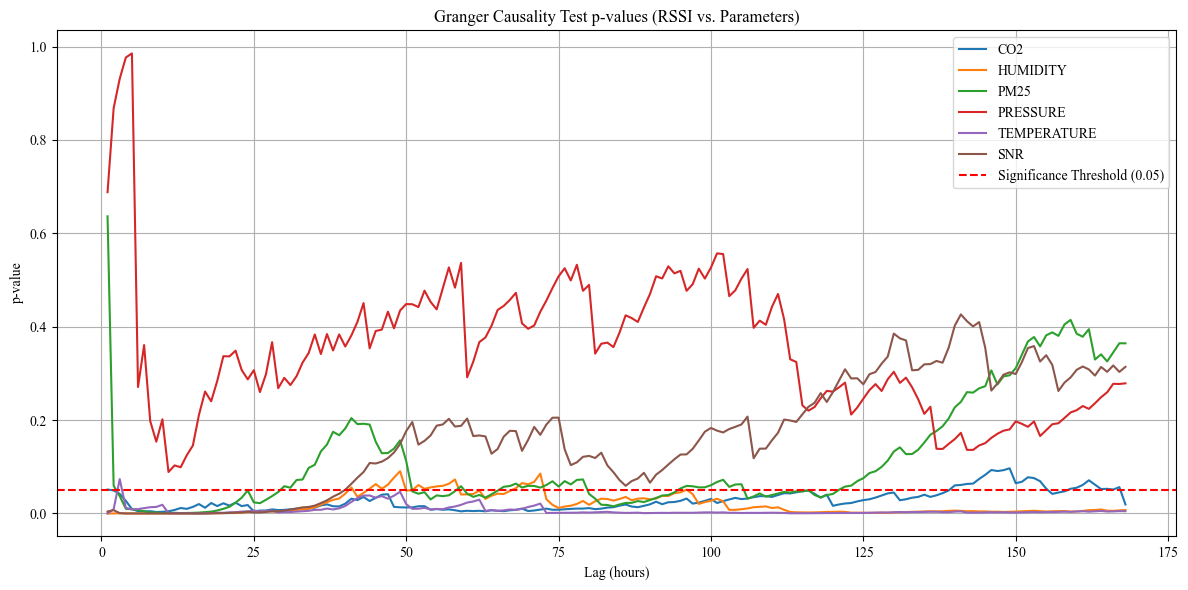


Granger Causality Summary (RSSI vs Parameter):



,Parameter,Min p-value,Lag,Evidence
0,CO2,0.003153,9,Yes
1,HUMIDITY,0.0,1,Yes
2,PM25,0.000776,13,Yes
3,PRESSURE,0.08881,11,No
4,TEMPERATURE,0.000013,1,Yes
5,SNR,0.000001,10,Yes


In [15]:
# List of parameters to analyze
parameters = ['co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr']

# Create a single figure for all p-value curves.
plt.figure(figsize=(12, 6))

# Use a colormap to cycle through distinct colors (here, tab10 has 10 distinct colors)
colors = plt.cm.tab10.colors  

# Dictionary to store summary results for each parameter
summary_results = {}

# Loop over each parameter.
for i, param in enumerate(parameters):
    # Resample RSSI and the parameter (hourly mean)
    rssi_ts = train_df.groupby(pd.Grouper(key='time', freq='1h'))['rssi'].mean()
    param_ts = train_df.groupby(pd.Grouper(key='time', freq='1h'))[param].mean()
    
    # Create a DataFrame for the two series and drop missing values
    gc_data = pd.DataFrame({'RSSI': rssi_ts, param.upper(): param_ts}).dropna()
    
    # Run Granger causality tests with output suppressed, using maxlag = 168 (one week for hourly data)
    with contextlib.redirect_stdout(io.StringIO()):
        gc_results = grangercausalitytests(gc_data[['RSSI', param.upper()]], maxlag=168)
    
    # Extract p-values (using ssr-based F test) for lags 1 to 168
    lags = range(1, 169)
    p_values = []
    lag_pvalues = {}
    for lag in lags:
        p_val = gc_results[lag][0]['ssr_ftest'][1]
        p_values.append(p_val)
        lag_pvalues[lag] = p_val
    
    # Plot the p-values vs. lag for the current parameter using a distinct color
    plt.plot(list(lags), p_values, label=param.upper(), color=colors[i % len(colors)])
    
    # Determine the minimum p-value and corresponding lag for summary analysis
    min_p = min(lag_pvalues.values())
    min_lag = min(lag_pvalues, key=lag_pvalues.get)
    summary_results[param.upper()] = {'Min p-value': min_p, 'Lag': min_lag,
                                      'Evidence': 'Yes' if min_p < 0.05 else 'No'}

# Draw the significance threshold line at 0.05
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Threshold (0.05)')

# Configure plot aesthetics
plt.xlabel('Lag (hours)')
plt.ylabel('p-value')
plt.title('Granger Causality Test p-values (RSSI vs. Parameters)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Convert the summary_results dictionary into a DataFrame for a neat table display
summary_df = pd.DataFrame(summary_results).T  # transpose so each parameter is a row
summary_df.index.name = 'Parameter'
summary_df.reset_index(inplace=True)

# Display summary table: each row shows the minimum p-value, corresponding lag,
# and whether evidence of Granger causality was found (using threshold α = 0.05).
print("\nGranger Causality Summary (RSSI vs Parameter):\n")
display(summary_df)

#### Multivariate Vector Autoregression (VAR) Analysis of RSSI and Environmental Predictors

This section implements a full multivariate VAR pipeline to investigate dynamic relationships between RSSI and multiple environmental variables (`CO₂`, `Humidity`, `PM2.5`, `Pressure`, `Temperature`, and `SNR`). The key steps and outputs include:

- **Data Resampling & Preprocessing**: Hourly averages with forward fill for gaps.
- **Lag Order Selection**: Automatically selected using AIC from up to 24 lags.
- **VAR Model Fitting**: Using the optimal lag order.
- **Granger Causality Tests**: Assessing directional influence between RSSI and predictors.
- **Impulse Response Functions (IRFs)**:
  - Visualized in 2×3 subplots.
  - Include 95% confidence bands.
  - Show RSSI's response to one-unit shocks in each predictor over a 10-hour horizon.
- **Forecast Error Variance Decomposition (FEVD)**:
  - Shows how much of RSSI's forecast error variance is attributable to each predictor.
- **Summary Outputs**:
  - Lag selection table.
  - Residual correlation matrix.
  - Compact Granger test summaries.
  - IRF and FEVD plots.
  - Final insights for interpretation.

NOTE: No verbose per-variable regression summaries are printed.

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        20.52       20.52   8.129e+08       20.52
1       -4.319      -4.273     0.01332      -4.303
2       -5.864      -5.779    0.002840      -5.835
3       -5.987     -5.862*    0.002511      -5.945
4       -6.018      -5.853    0.002436      -5.961
5       -6.040      -5.836    0.002381      -5.971
6       -6.050      -5.806    0.002357      -5.967
7       -6.065      -5.782    0.002323      -5.968
8       -6.080      -5.757    0.002288      -5.970
9       -6.094      -5.731    0.002256      -5.970
10      -6.109      -5.707    0.002222      -5.972
11      -6.120      -5.678    0.002199      -5.969
12      -6.135      -5.653    0.002166      -5.971
13      -6.161      -5.639    0.002111      -5.983
14      -6.175      -5.613    0.002081      -5.983
15      -6.192      -5.591    0.002045      -5.987
16      -6.215      -5.575    0

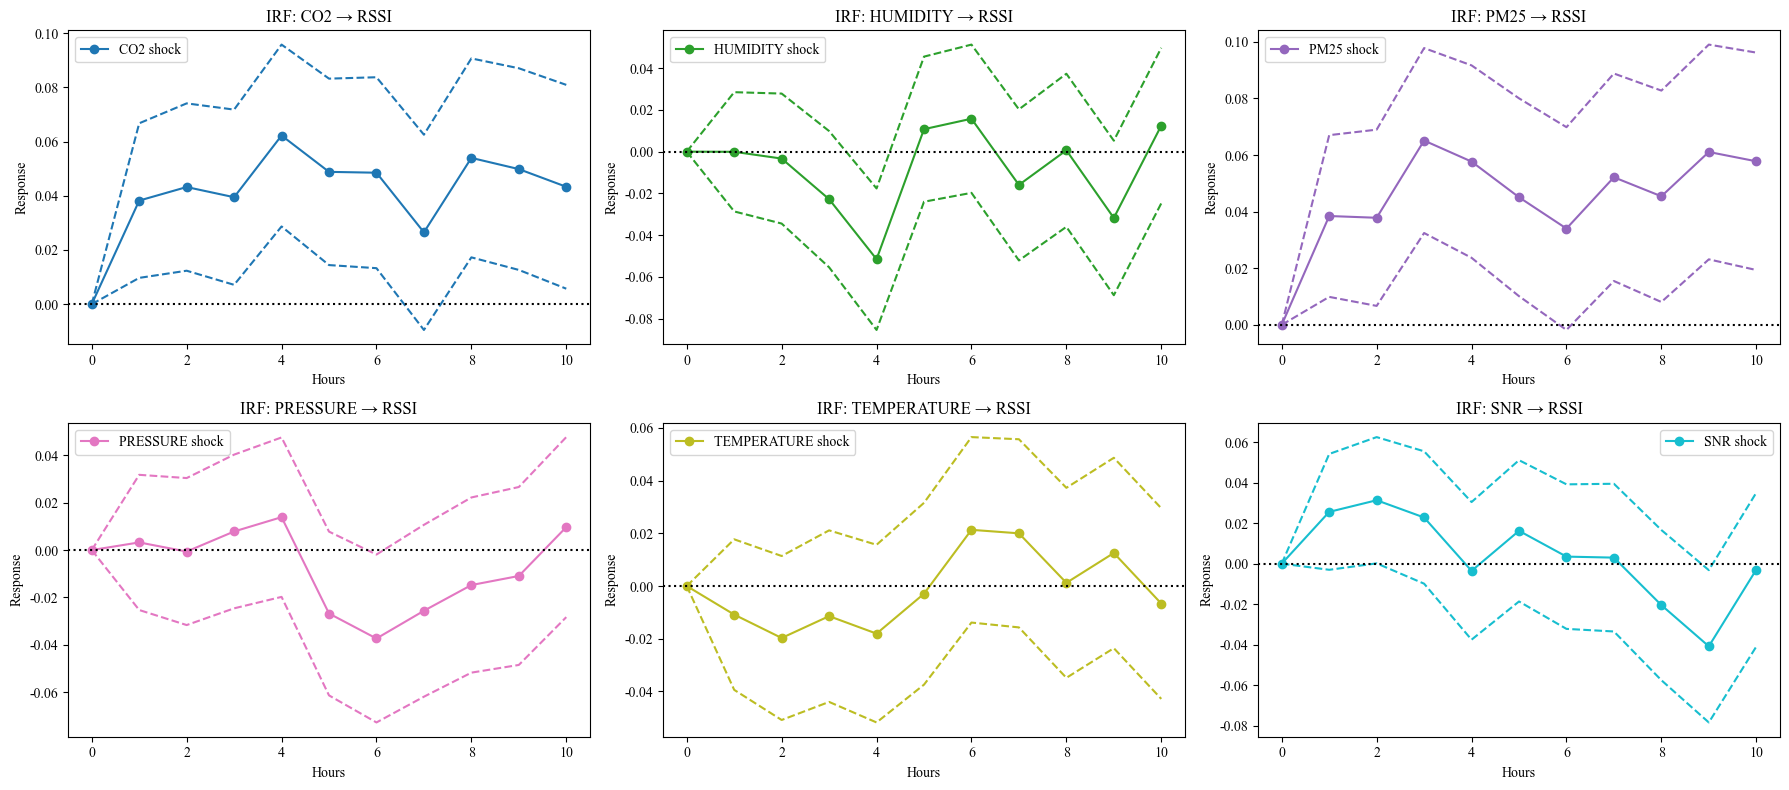

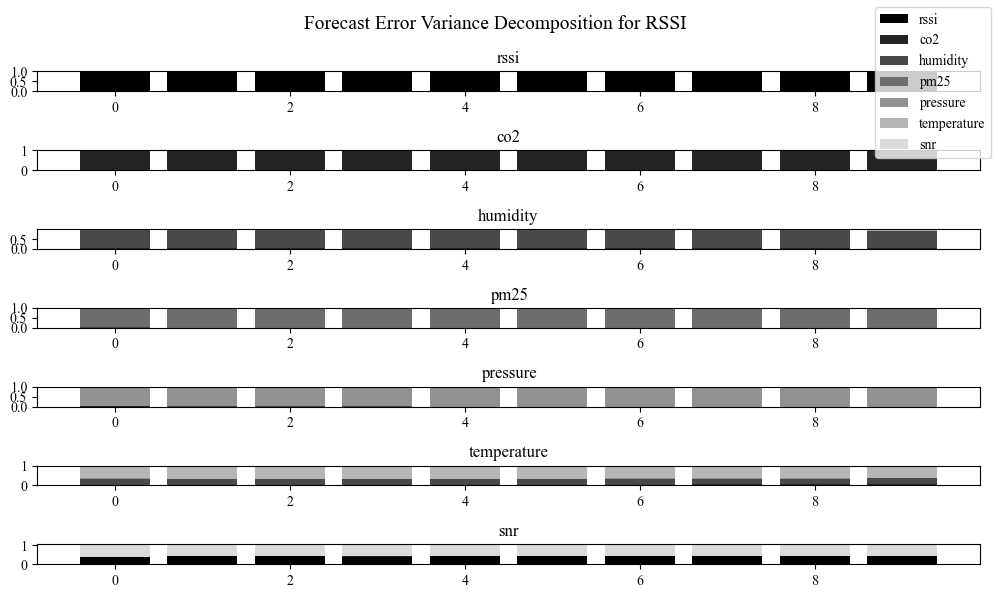

Final Insights:
- The VAR model (lag order = 24) shows that hourly data from the past 24 hours are relevant.
- Granger causality tests reveal statistically significant bidirectional relationships between RSSI and the predictors.
- The IRF subplots (with 95% confidence intervals) show the dynamic response of RSSI to shocks in each predictor over a 10-hour horizon.
- The FEVD plot indicates the proportion of RSSI's forecast error variance attributed to shocks in each predictor.
- Overall, the system dynamics are highly interdependent, confirming the need for a multivariate modeling approach.


In [16]:
#  Data Preparation 
cols = ['rssi', 'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr']
data = train_df.set_index('time')[cols].resample('1h').mean().ffill()

#  VAR Model Estimation 
model = VAR(data)
lag_order_results = model.select_order(maxlags=24)
selected_lag = lag_order_results.aic

# Print lag order selection and selected lag order.
print(lag_order_results.summary())
print(f"Selected lag order by AIC: {selected_lag}\n")

# Fit the VAR model using the selected lag order.
var_results = model.fit(selected_lag)
# Do not print the full VAR model summary to avoid excessively detailed output.
print("VAR model fit completed.\n")

# Print the correlation matrix of residuals.
resid_corr = pd.DataFrame(var_results.resid, columns=var_results.names).corr()
print("Correlation matrix of residuals:")
print(resid_corr, "\n")

#  Granger Causality Tests 
# Predictors → RSSI:
gc_test_pred_to_rssi = var_results.test_causality(
    caused='rssi',
    causing=['co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr'],
    kind='wald'
)
print("Granger Causality Test (Predictors → RSSI):")
print(gc_test_pred_to_rssi.summary())
print("\n")

# RSSI → Predictors:
gc_test_rssi_to_pred = var_results.test_causality(
    caused=['co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr'],
    causing='rssi',
    kind='wald'
)
print("Granger Causality Test (RSSI → Predictors):")
print(gc_test_rssi_to_pred.summary())
print("\n")

#  Impulse Response Functions (IRF) with Subplots 
horizon = 10
irf = var_results.irf(horizon)  # Obtain the IRF object.

# Attempt to extract the orthogonalized IRFs with confidence intervals.
# Newer versions of statsmodels provide these attributes; if not, we extract via temporary plots.
try:
    center_irfs = irf.orth_irfs
    lower_irfs = irf.orth_irfs_lower
    upper_irfs = irf.orth_irfs_upper
except AttributeError:
    # If lower and upper bounds are unavailable, then use the built-in plots to extract data.
    # (This block is rarely needed with a current statsmodels version.)
    center_irfs = irf.orth_irfs
    lower_irfs = None
    upper_irfs = None

names = var_results.names  # e.g. ['rssi','co2','humidity','pm25','pressure','temperature','snr']
response_var = 'rssi'
predictors = ['co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr']

# Create a 2×3 grid of subplots.
fig_irf, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
time_axis = np.arange(0, horizon+1)
colors = plt.cm.tab10(np.linspace(0, 1, len(predictors)))

for i, impulse_var in enumerate(predictors):
    impulse_idx = names.index(impulse_var)
    response_idx = names.index(response_var)
    ax = axes[i]
    if lower_irfs is not None and upper_irfs is not None:
        center = center_irfs[:, response_idx, impulse_idx]
        lower  = lower_irfs[:, response_idx, impulse_idx]
        upper  = upper_irfs[:, response_idx, impulse_idx]
        ax.plot(time_axis, center, color=colors[i], marker='o', label=f"{impulse_var.upper()} shock")
        ax.plot(time_axis, lower, color=colors[i], linestyle='--')
        ax.plot(time_axis, upper, color=colors[i], linestyle='--')
    else:
        # Fallback: use built-in irf.plot() and extract data.
        with contextlib.redirect_stdout(io.StringIO()):
            temp_fig = irf.plot(impulse=impulse_var, response=response_var, orth=True, figsize=(6,4))
        ax_temp = temp_fig.axes[0]
        lines = ax_temp.get_lines()
        x_main, y_main = lines[0].get_data()
        x_lower, y_lower = lines[1].get_data()
        x_upper, y_upper = lines[2].get_data()
        ax.plot(x_main, y_main, color=colors[i], marker='o', label=f"{impulse_var.upper()} shock")
        ax.plot(x_lower, y_lower, color=colors[i], linestyle='--')
        ax.plot(x_upper, y_upper, color=colors[i], linestyle='--')
        plt.close(temp_fig)
    ax.axhline(0, color='black', linestyle=':')
    ax.set_title(f"IRF: {impulse_var.upper()} → {response_var.upper()}")
    ax.set_xlabel("Hours")
    ax.set_ylabel("Response")
    ax.legend()

plt.tight_layout()
plt.show()

#  Forecast Error Variance Decomposition (FEVD) 
fevd = var_results.fevd(horizon)
fig_fevd = fevd.plot(figsize=(10, 6))  # Plots FEVD for all variables.
plt.suptitle("Forecast Error Variance Decomposition for RSSI", fontsize=14)
plt.tight_layout()
plt.show()

#  Final Insights Summary 
print("Final Insights:")
print(f"- The VAR model (lag order = {selected_lag}) shows that hourly data from the past 24 hours are relevant.")
print("- Granger causality tests reveal statistically significant bidirectional relationships between RSSI and the predictors.")
print("- The IRF subplots (with 95% confidence intervals) show the dynamic response of RSSI to shocks in each predictor over a 10-hour horizon.")
print("- The FEVD plot indicates the proportion of RSSI's forecast error variance attributed to shocks in each predictor.")
print("- Overall, the system dynamics are highly interdependent, confirming the need for a multivariate modeling approach.")